# AHN Compressive Memory 


**Model:** Qwen2.5-3B-Instruct + AHN-GatedDeltaNet-3B (loaded from HF)  
**Sliding window:** taken from AHN config (~128 in pilot merged config)

## 1. Setup and load model

Loads Qwen2.5-3B base + AHN-GDN adapter. Does NOT write a merged checkpoint to disk.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '6'
import torch
print(torch.cuda.get_device_name(0))
print("Free VRAM:", torch.cuda.mem_get_info(0)[0]/1e9, "GB")

NVIDIA A100-SXM4-40GB
Free VRAM: 41.96040704 GB


In [3]:
import os, json, torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from ahn.transformer.qwen2_ahn import register_customized_qwen2

register_customized_qwen2()

MODEL_PATH = "/home/jupyter-dphs-4ca1/AHN/merged_ckpt/Qwen-2.5-Instruct-3B-AHN-GDN"
RESULTS_DIR = "/home/jupyter-dphs-4ca1/AHN/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Loading merged model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
    attn_implementation="flash_attention_2",
)

model.eval()
unembed = model.lm_head.weight  # [vocab, hidden]
VOCAB_SIZE, HIDDEN = unembed.shape
SLIDING_WINDOW = model.config.sliding_window
N_LAYERS = model.config.num_hidden_layers

print(f"\nModel:  Qwen2.5-3B + AHN-GDN")
print(f"Vocab:  {VOCAB_SIZE}, Hidden: {HIDDEN}, Layers: {N_LAYERS}")
print(f"Window: {SLIDING_WINDOW}")

Loading merged model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Model:  Qwen2.5-3B + AHN-GDN
Vocab:  151936, Hidden: 2048, Layers: 36
Window: 256


## 2. Hook infrastructure

For AHN-on runs we install capture only.

## 2. Hook infrastructure (fixed)

**The fix:** we no longer install both capture and zero hooks and hope the order is right. Instead:
- Capture hook is a `forward_hook` that reads `output` and stores it.
- NOWRITE is done with a hook that returns `zeros_like(output)`. When it runs, it becomes the new output.
- We install NOWRITE FIRST, then capture. PyTorch fires hooks in registration order → NOWRITE modifies output → capture sees zeros.

For AHN-on runs we install capture only.

In [4]:
def get_ahn_layers(model):
    return [(i, l) for i, l in enumerate(model.model.layers) if hasattr(l, 'ahn')]

def clear_all_hooks(model):
    for _, l in get_ahn_layers(model):
        l.ahn._forward_hooks.clear()
        l.ahn._forward_pre_hooks.clear()

def make_capture_hook(store, idx):
    def hook(module, inp, out):
        t = out[0] if isinstance(out, tuple) else out
        store[idx] = t.detach().clone()
    return hook

def zero_hook(module, inp, out):
    if isinstance(out, tuple):
        return (torch.zeros_like(out[0]),) + out[1:]
    return torch.zeros_like(out)

def run_capture(model, inputs, nowrite=False):
    """Run one forward pass, capturing AHN outputs.
    If nowrite=True, AHN outputs are zeroed BEFORE capture sees them."""
    clear_all_hooks(model)
    store = {}
    for idx, layer in get_ahn_layers(model):
        if nowrite:
            layer.ahn.register_forward_hook(zero_hook)  # runs first
        layer.ahn.register_forward_hook(make_capture_hook(store, idx))  # runs after
    with torch.no_grad():
        model(**inputs, use_cache=True)
    clear_all_hooks(model)
    return store

def last_pos_vec(store, layer_idx):
    t = store[layer_idx].squeeze(0)  # remove batch
    if t.dim() > 1:
        t = t[-1]  # last sequence position
    return t

print("Hook infrastructure ready.")
print(f"AHN layers detected: {len(get_ahn_layers(model))}/{N_LAYERS}")

Hook infrastructure ready.
AHN layers detected: 36/36


## 2b. Sanity check: NOWRITE actually zeros the capture

If this fails, all downstream Δ-readout numbers are meaningless. Non-negotiable check.

In [5]:
FILLER = "The quick brown fox jumps. "
test_prompt = f"The special word is 42. {FILLER * 100} What was the special word?"
test_inputs = tokenizer(test_prompt, return_tensors="pt").to("cuda")
n_toks = test_inputs['input_ids'].shape[1]
print(f"Prompt tokens: {n_toks}, sliding window: {SLIDING_WINDOW}, AHN should be active: {n_toks > SLIDING_WINDOW}")

ahn_on  = run_capture(model, test_inputs, nowrite=False)
ahn_off = run_capture(model, test_inputs, nowrite=True)

# Check: NOWRITE captures must be exactly zero. AHN-on captures must not.
mid = N_LAYERS // 2
on_norm  = last_pos_vec(ahn_on,  mid).abs().sum().item()
off_norm = last_pos_vec(ahn_off, mid).abs().sum().item()
print(f"Layer {mid} AHN-on |o_t| sum:  {on_norm:.4f}")
print(f"Layer {mid} NOWRITE |o_t| sum: {off_norm:.4f}   (must be 0)")
assert off_norm == 0.0, "NOWRITE hook did NOT zero the capture. Hook ordering broken."
assert on_norm  > 0.0,  "AHN-on capture is zero. Something else is wrong."
print("\n[OK] NOWRITE fires before capture. Δ-readout will be meaningful.")

Prompt tokens: 615, sliding window: 256, AHN should be active: True
Layer 18 AHN-on |o_t| sum:  18.2500
Layer 18 NOWRITE |o_t| sum: 0.0000   (must be 0)

[OK] NOWRITE fires before capture. Δ-readout will be meaningful.


## 3. Layer profile — which layers is AHN actually doing work in?

For each layer, compute ||o_t^(AHN)||. AHN-off is zero everywhere by construction now (from Section 2b), so 'AHN contribution' just = the AHN-on norm per layer.

Active layers (>6.40 = 10% of peak): 34/36
Range: 0-35


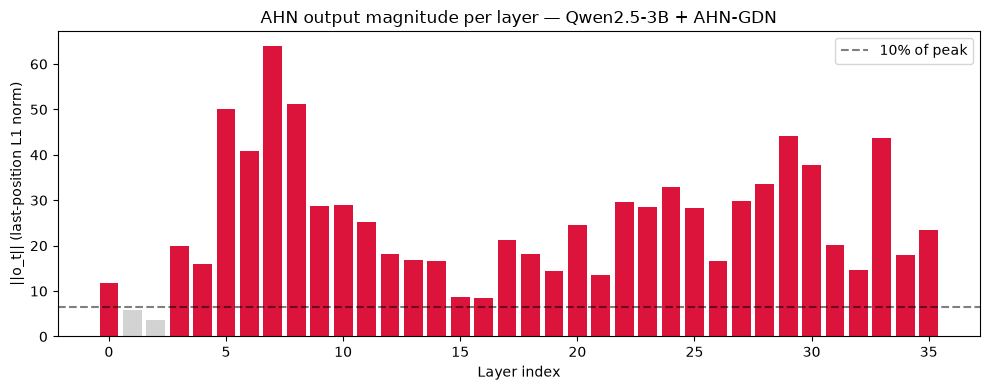

In [6]:
contributions = {}
for i in sorted(ahn_on.keys()):
    contributions[i] = last_pos_vec(ahn_on, i).abs().sum().item()

vals = np.array(list(contributions.values()))
threshold = 0.1 * vals.max()  # 10% of peak
active = [i for i, v in contributions.items() if v > threshold]
print(f"Active layers (>{threshold:.2f} = 10% of peak): {len(active)}/{N_LAYERS}")
print(f"Range: {active[0]}-{active[-1]}")

fig, ax = plt.subplots(figsize=(10, 4))
layers = list(contributions.keys())
colors = ['crimson' if v > threshold else 'lightgray' for v in contributions.values()]
ax.bar(layers, list(contributions.values()), color=colors)
ax.axhline(y=threshold, color='k', linestyle='--', alpha=0.5, label='10% of peak')
ax.set_xlabel('Layer index')
ax.set_ylabel('||o_t|| (last-position L1 norm)')
ax.set_title('AHN output magnitude per layer — Qwen2.5-3B + AHN-GDN')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/layer_profile.png', dpi=120)
plt.show()

with open(f'{RESULTS_DIR}/layer_profile.json', 'w') as f:
    json.dump(contributions, f, indent=2)

## 4. Multi-needle Δ-readout across layers

For each needle: rank of needle token in `logit_lens(o_t^AHN - o_t^NOWRITE)`.

Since NOWRITE = 0 for AHN outputs (verified in 2b), Δ = o_t^AHN. So this is effectively logit-lens on the raw AHN output. This is a **pilot** — proper J-lens comes later.

Paris   : min_rank=  7136  median= 84460  best_layer=35
  WARN: '42' tokenizes to 3 tokens [220, 19, 17], skipping
banana  : min_rank= 12913  median= 83138  best_layer=25


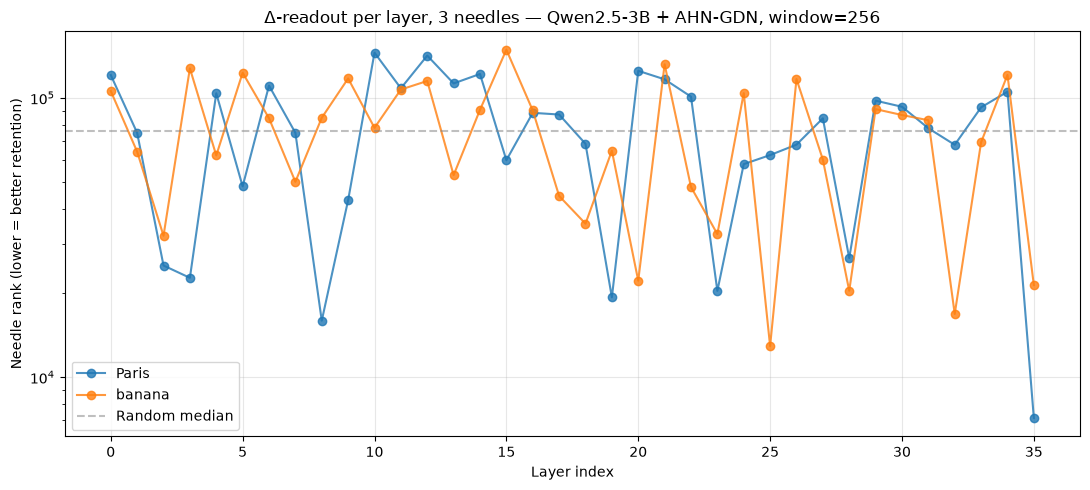

In [7]:
NEEDLES = ["Paris", "42", "banana"]

def encode_needle(needle):
    """Return single token id for needle, or None if it splits."""
    ids = tokenizer.encode(f" {needle}", add_special_tokens=False)
    if len(ids) != 1:
        print(f"  WARN: '{needle}' tokenizes to {len(ids)} tokens {ids}, skipping")
        return None
    return ids[0]

def rank_of_token_in_readout(vec, token_id):
    logits = vec.float() @ unembed.float().T
    order = logits.argsort(descending=True)
    return (order == token_id).nonzero()[0].item()

delta_results = {}
for needle in NEEDLES:
    nid = encode_needle(needle)
    if nid is None:
        continue
    prompt = f"The special word is {needle}. {FILLER * 100} What was the special word?"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    on  = run_capture(model, inputs, nowrite=False)
    off = run_capture(model, inputs, nowrite=True)
    ranks = {}
    for i in on:
        delta = last_pos_vec(on, i) - last_pos_vec(off, i)
        ranks[i] = rank_of_token_in_readout(delta, nid)
    delta_results[needle] = ranks
    vs = list(ranks.values())
    print(f"{needle:8s}: min_rank={min(vs):6d}  median={sorted(vs)[len(vs)//2]:6d}  best_layer={min(ranks, key=ranks.get)}")

fig, ax = plt.subplots(figsize=(11, 5))
for needle, ranks in delta_results.items():
    xs = sorted(ranks.keys())
    ys = [ranks[x] for x in xs]
    ax.plot(xs, ys, marker='o', label=needle, alpha=0.8)
ax.axhline(y=VOCAB_SIZE//2, color='gray', linestyle='--', alpha=0.5, label='Random median')
ax.set_yscale('log')
ax.set_xlabel('Layer index')
ax.set_ylabel('Needle rank (lower = better retention)')
ax.set_title(f'Δ-readout per layer, 3 needles — Qwen2.5-3B + AHN-GDN, window={SLIDING_WINDOW}')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/multi_needle_delta.png', dpi=120)
plt.show()

with open(f'{RESULTS_DIR}/multi_needle_delta.json', 'w') as f:
    json.dump({k: {str(i): r for i, r in v.items()} for k, v in delta_results.items()}, f, indent=2)

## 5. Retention decay + pre-eviction baseline control

Two runs per eviction distance:
- **In-window (baseline):** needle at end of prompt, before window edge. Rank ceiling.
- **Evicted:** needle at start, filler pushes it past the window.

Compare decay to baseline instead of just to random.

Best layers from Section 4: {'Paris': 35, 'banana': 25}
Paris: baseline=110712, decay={348: (63676, 41888), 948: (98262, 19341), 1548: (103139, 15077), 2148: (97912, 12525), 3348: (93323, 8406), 5748: (94576, 9570)}
banana: baseline=99822, decay={348: (33887, 7424), 948: (35171, 38837), 1548: (34637, 39892), 2148: (35117, 37897), 3348: (33959, 37218), 5748: (35232, 38143)}


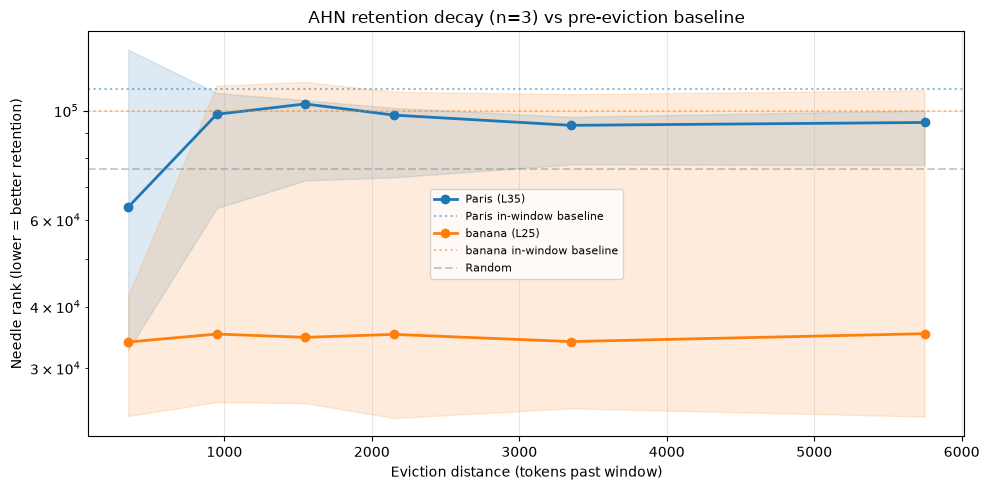

In [8]:
BEST_LAYERS = {n: min(delta_results[n], key=delta_results[n].get) for n in delta_results}
FILLER_COUNTS = [50, 100, 150, 200, 300, 500]
N_SAMPLES = 3

print("Best layers from Section 4:", BEST_LAYERS)

def measure_rank(prompt, needle_id, best_layer):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    on  = run_capture(model, inputs, nowrite=False)
    off = run_capture(model, inputs, nowrite=True)
    if best_layer not in on:
        return None  # AHN didn't activate
    delta = last_pos_vec(on, best_layer) - last_pos_vec(off, best_layer)
    return rank_of_token_in_readout(delta, needle_id)

FILLERS = [
    "The quick brown fox jumps over the lazy dog. ",
    "Lorem ipsum dolor sit amet consectetur adipiscing. ",
    "In a hole in the ground there lived a hobbit. ",
]

decay_curves = {}
baseline_ranks = {}

for needle, best_layer in BEST_LAYERS.items():
    nid = encode_needle(needle)
    curve = {}

    # Pre-eviction baseline: needle at end, big filler prefix to guarantee AHN active
    base_prompt = f"{FILLERS[0] * 80}The special word is {needle}. What was the special word?"
    baseline_ranks[needle] = measure_rank(base_prompt, nid, best_layer)

    # Evicted: needle at start, varying filler
    for n_fill in FILLER_COUNTS:
        ranks_here = []
        for filler in FILLERS[:N_SAMPLES]:
            prompt = f"The special word is {needle}. " + filler * n_fill + "What was the special word?"
            inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
            n_toks = inputs['input_ids'].shape[1]
            eviction = max(0, n_toks - SLIDING_WINDOW - 8)
            r = measure_rank(prompt, nid, best_layer)
            if r is not None:
                ranks_here.append(r)
        if ranks_here:
            curve[eviction] = ranks_here
    decay_curves[needle] = curve
    print(f"{needle}: baseline={baseline_ranks[needle]}, decay={ {k: (int(np.median(v)), int(np.std(v))) for k,v in curve.items()} }")

fig, ax = plt.subplots(figsize=(10, 5))
for needle, curve in decay_curves.items():
    xs = sorted(curve.keys())
    medians = [np.median(curve[x]) for x in xs]
    lows    = [np.min(curve[x])    for x in xs]
    highs   = [np.max(curve[x])    for x in xs]
    line, = ax.plot(xs, medians, marker='o', linewidth=2, label=f"{needle} (L{BEST_LAYERS[needle]})")
    ax.fill_between(xs, lows, highs, alpha=0.15, color=line.get_color())
    if baseline_ranks[needle] is not None:
        ax.axhline(y=baseline_ranks[needle], color=line.get_color(), linestyle=':', alpha=0.5,
                   label=f"{needle} in-window baseline")
ax.axhline(y=VOCAB_SIZE//2, color='gray', linestyle='--', alpha=0.4, label='Random')
ax.set_yscale('log')
ax.set_xlabel('Eviction distance (tokens past window)')
ax.set_ylabel('Needle rank (lower = better retention)')
ax.set_title(f'AHN retention decay (n={N_SAMPLES}) vs pre-eviction baseline')
ax.legend(fontsize=8, loc='best'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/retention_decay.png', dpi=120)
plt.show()

with open(f'{RESULTS_DIR}/retention_decay.json', 'w') as f:
    json.dump({
        'baseline': baseline_ranks,
        'decay': {k: {str(i): r for i, r in v.items()} for k, v in decay_curves.items()},
        'best_layers': BEST_LAYERS,
    }, f, indent=2)

In [9]:
from datasets import load_dataset


ds = load_dataset('simonjegou/ruler', '4096', split='test', streaming=True)
examples = list(ds.take(20))
print(examples[0].keys())
print(examples[0])

README.md: 0.00B [00:00, ?B/s]

dict_keys(['context', 'question', 'answer_prefix', 'answer', 'task', 'max_new_tokens'])
{'context': 'A special magic number is hidden within the following text. Make sure to memorize it. I will quiz you about the number afterwards.\nThe grass is green. The sky is blue. The sun is yellow. Here we go. There and back again.\nThe grass is green. The sky is blue. The sun is yellow. Here we go. There and back again.\nThe grass is green. The sky is blue. The sun is yellow. Here we go. There and back again.\nThe grass is green. The sky is blue. The sun is yellow. Here we go. There and back again.\nThe grass is green. The sky is blue. The sun is yellow. Here we go. There and back again.\nThe grass is green. The sky is blue. The sun is yellow. Here we go. There and back again.\nThe grass is green. The sky is blue. The sun is yellow. Here we go. There and back again.\nThe grass is green. The sky is blue. The sun is yellow. Here we go. There and back again.\nThe grass is green. The sky is blue. Th

In [10]:
usable = []
for ex in examples:
    prompt = ex["context"] + ex["question"] + ex["answer_prefix"]
    usable.append({"prompt": prompt, "answer": ex["answer"][0]})

results = []
for i, u in enumerate(usable):
    inputs = tokenizer(u["prompt"], return_tensors="pt").to("cuda")
    n_toks = inputs["input_ids"].shape[1]

    if n_toks <= SLIDING_WINDOW:
        print(f"[{i+1:02d}/{len(usable)}] SKIP | tokens={n_toks} <= window={SLIDING_WINDOW}")
        del inputs
        continue

    on = run_capture(model, inputs, nowrite=False)
    off = run_capture(model, inputs, nowrite=True)

    common_layers = sorted(set(on) & set(off))

    if not common_layers:
        print(f"[{i+1:02d}/{len(usable)}] FAIL | no AHN layers captured")
        results.append({"write_active": False, "nowrite_zero": False})
        del inputs, on, off
        continue

    on_norms = [last_pos_vec(on, L).float().norm().item() for L in common_layers]
    off_norms = [last_pos_vec(off, L).float().norm().item() for L in common_layers]

    write_mean = float(np.mean(on_norms))
    write_active = max(on_norms) > 0.0
    nowrite_zero = max(off_norms) == 0.0

    results.append({
        "write_active": write_active,
        "nowrite_zero": nowrite_zero
    })

    status = "PASS" if write_active and nowrite_zero else "CHECK"
    print(f"[{i+1:02d}/{len(usable)}] tokens={n_toks} | layers={len(common_layers)} | WRITE={write_mean:.4f} | NOWRITE={max(off_norms):.4f} | {status}")

    del inputs, on, off

n = len(results)
write_pass = sum(r["write_active"] for r in results)
nowrite_pass = sum(r["nowrite_zero"] for r in results)

print("\n=== REAL-DATA HOOK VALIDATION ===")
print(f"Examples tested : {n}")
print(f"WRITE active    : {write_pass}/{n}")
print(f"NOWRITE zero    : {nowrite_pass}/{n}")

if n > 0 and write_pass == n and nowrite_pass == n:
    print("✅ PASS — hook validation complete. Move to J-Lens.")
else:
    print("❌ CHECK — inspect failed examples before moving on.")

[01/20] tokens=3675 | layers=36 | WRITE=0.8829 | NOWRITE=0.0000 | PASS
[02/20] tokens=3678 | layers=36 | WRITE=0.9281 | NOWRITE=0.0000 | PASS
[03/20] tokens=3675 | layers=36 | WRITE=0.9027 | NOWRITE=0.0000 | PASS
[04/20] tokens=3681 | layers=36 | WRITE=0.9489 | NOWRITE=0.0000 | PASS
[05/20] tokens=3681 | layers=36 | WRITE=0.9389 | NOWRITE=0.0000 | PASS
[06/20] tokens=3687 | layers=36 | WRITE=0.9438 | NOWRITE=0.0000 | PASS
[07/20] tokens=3681 | layers=36 | WRITE=0.8759 | NOWRITE=0.0000 | PASS
[08/20] tokens=3681 | layers=36 | WRITE=0.9220 | NOWRITE=0.0000 | PASS
[09/20] tokens=3681 | layers=36 | WRITE=0.9202 | NOWRITE=0.0000 | PASS
[10/20] tokens=3678 | layers=36 | WRITE=0.9315 | NOWRITE=0.0000 | PASS
[11/20] tokens=3681 | layers=36 | WRITE=0.9363 | NOWRITE=0.0000 | PASS
[12/20] tokens=3678 | layers=36 | WRITE=0.9322 | NOWRITE=0.0000 | PASS
[13/20] tokens=3678 | layers=36 | WRITE=0.9741 | NOWRITE=0.0000 | PASS
[14/20] tokens=3681 | layers=36 | WRITE=0.9459 | NOWRITE=0.0000 | PASS
[15/20

In [11]:
import inspect

ahn_layers = get_ahn_layers(model)
idx, layer = ahn_layers[len(ahn_layers) // 2]

print(f"Inspecting layer {idx}")
print("\nAHN MODULE:")
print(layer.ahn)

print("\n=== AHN FORWARD SOURCE ===")
try:
    print(inspect.getsource(layer.ahn.forward))
except Exception as e:
    print("Could not print AHN forward source:", e)

print("\n=== PARENT LAYER FORWARD SOURCE ===")
try:
    print(inspect.getsource(layer.forward))
except Exception as e:
    print("Could not print parent forward source:", e)

captured = {}

def inspect_hook(module, inp, out):
    captured["input_shapes"] = [
        tuple(x.shape) if torch.is_tensor(x) else type(x).__name__
        for x in inp
    ]

    if isinstance(out, tuple):
        captured["output_type"] = "tuple"
        captured["output_shapes"] = [
            tuple(x.shape) if torch.is_tensor(x) else type(x).__name__
            for x in out
        ]
    else:
        captured["output_type"] = type(out).__name__
        captured["output_shape"] = tuple(out.shape) if torch.is_tensor(out) else None

handle = layer.ahn.register_forward_hook(inspect_hook)

ex = examples[0]
prompt = ex["context"] + ex["question"] + ex["answer_prefix"]
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.inference_mode():
    _ = model(**inputs, use_cache=True)

handle.remove()

print("\n=== ACTUAL HOOK I/O ===")
for k, v in captured.items():
    print(f"{k}: {v}")

del inputs

Inspecting layer 18

AHN MODULE:
BaseAHN(
  (fn): GatedDeltaNet(
    (b_proj): Linear(in_features=2048, out_features=16, bias=False)
    (a_proj): Linear(in_features=2048, out_features=16, bias=False)
    (g_proj): Linear(in_features=2048, out_features=16, bias=False)
    (o_norm): FusedRMSNormSwishGate(128, eps=1e-05, activation=swish)
    (o_proj): GroupLinear()
  )
)

=== AHN FORWARD SOURCE ===
    def forward(
        self,
        hidden_states: torch.Tensor,
        q_states: torch.Tensor,
        k_states: torch.Tensor,
        v_states: torch.Tensor,
        use_cache: bool = False,
        past_key_values: Optional[Cache] = None,
    ):
        o, _, past_key_values = self.fn(
            layer_idx=self.layer_idx,
            hidden_states=hidden_states,
            q_states=q_states,
            k_states=k_states,
            v_states=v_states,
            use_cache=use_cache,
            past_key_values=past_key_values,
        )

        if not self.training:
            se

In [12]:
print("=== GATED DELTANET FORWARD SOURCE ===")
print(inspect.getsource(layer.ahn.fn.forward))


=== GATED DELTANET FORWARD SOURCE ===
    def forward(
        self,
        hidden_states: torch.Tensor,
        q_states: torch.Tensor,
        k_states: torch.Tensor,
        v_states: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        use_cache: Optional[bool] = False,
        past_key_values: Optional[Cache] = None,
        output_attentions: Optional[bool] = False,
        **kwargs: Unpack[Dict],
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor], Optional[Cache]]:
        if attention_mask is not None:
            assert len(attention_mask.shape) == 2, (
                "Expected attention_mask as a 0-1 matrix with shape [batch_size, seq_len] "
                "for padding purposes (0 indicating padding). "
                "Arbitrary attention masks of shape [batch_size, seq_len, seq_len] are not allowed."
            )

        last_state = None
        if past_key_values is not None and len(past_key_values) > self.layer_idx:
            last_state = 

In [13]:
class AHNJacobianLens:
    def __init__(self, jacobians, lm_head):
        self.jacobians = jacobians
        self.lm_head = lm_head

    @torch.no_grad()
    def transport(self, ahn_output, layer):
        J = self.jacobians[layer].to(
            device=ahn_output.device,
            dtype=torch.float32
        )
        return ahn_output.float() @ J.T

    @torch.no_grad()
    def decode(self, ahn_output, layer):
        transported = self.transport(ahn_output, layer)
        logits = self.lm_head(
            transported.to(self.lm_head.weight.dtype)
        )
        return logits.float()

In [26]:
J18 = torch.load('/home/jupyter-dphs-4ca1/J18_qwen25_3b (2).pt', map_location='cuda')
print('Shape:', J18.shape, 'dtype:', J18.dtype)

Shape: torch.Size([2048, 2048]) dtype: torch.float32


/tmp/ipykernel_1442043/1765099481.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  J18 = torch.load('/home/jupyter-dphs-4ca1/J18_qwen25_3b (2).pt', map_location='cuda')


In [29]:
J18 = torch.load(
    "J18_qwen25_3b (2).pt",
    map_location="cuda",
    weights_only=True
).float()

ahn_lens = AHNJacobianLens(
    jacobians={18: J18},
    lm_head=model.lm_head
)

print("J18 loaded:", J18.shape)
print("Norm:", J18.norm().item())
print("AHN-JLens adapter ready ✅")

J18 loaded: torch.Size([2048, 2048])
Norm: 66.89842224121094
AHN-JLens adapter ready ✅


In [31]:
import gc

if "ahn_lens" in globals():
    del ahn_lens
if "J18" in globals():
    del J18

gc.collect()
torch.cuda.empty_cache()

J18 = torch.load(
    "J18_qwen25_3b (2).pt",
    map_location="cuda",
    weights_only=True
).float()

ahn_lens = AHNJacobianLens(
    jacobians={18: J18},
    lm_head=model.lm_head
)

print("Reloaded:", J18.shape)
print("Norm:", J18.norm().item())
print("Ready ✅")



Reloaded: torch.Size([2048, 2048])
Norm: 66.89842224121094
Ready ✅


In [32]:
ex = examples[0]
prompt = ex["context"] + ex["question"] + ex["answer_prefix"]
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

capture = {}

def hook_l18(module, inp, out):
    capture["o18"] = out[0] if isinstance(out, tuple) else out

handle = model.model.layers[18].ahn.register_forward_hook(hook_l18)

with torch.inference_mode():
    _ = model(**inputs, use_cache=True)

handle.remove()

o18 = capture["o18"][0, -1]

logits = ahn_lens.decode(o18, layer=18)

topk = torch.topk(logits, 20)

print("AHN output:", o18.shape)
print("\nTop-20 decoded tokens:")

for idx, score in zip(topk.indices, topk.values):
    print(repr(tokenizer.decode([idx.item()])), float(score))

AHN output: torch.Size([2048])

Top-20 decoded tokens:
' […' 0.1904296875
' visual' 0.1875
'[…]' 0.185546875
'–' 0.1845703125
' –' 0.18359375
',' 0.1826171875
' visuals' 0.17578125
'—' 0.17578125
'\u200b' 0.1728515625
' […]' 0.171875
'…' 0.1708984375
' vision' 0.169921875
'…\n\n\n' 0.166015625
'[…' 0.166015625
' Visual' 0.1650390625
'“' 0.1640625
'…\n' 0.1630859375
'….' 0.1611328125
'\xadtion' 0.16015625
'\n' 0.1591796875


In [33]:
# Capture Layer-18 residual + AHN output
store = {}

def ahn_hook(module, inp, out):
    store["o18"] = out[0] if isinstance(out, tuple) else out

def layer_hook(module, inp, out):
    store["h18"] = out[0] if isinstance(out, tuple) else out

h1 = model.model.layers[18].ahn.register_forward_hook(ahn_hook)
h2 = model.model.layers[18].register_forward_hook(layer_hook)

ex = examples[0]
prompt = ex["context"] + ex["question"] + ex["answer_prefix"]
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.inference_mode():
    _ = model(**inputs, use_cache=True)

h1.remove()
h2.remove()

o18 = store["o18"][0, -1]
h18 = store["h18"][0, -1]

print("AHN o18 norm:", o18.float().norm().item())
print("Full h18 norm:", h18.float().norm().item())

# Decode FULL residual with J-Lens
transported = h18.float() @ J18.T
logits = model.lm_head(
    transported.to(model.lm_head.weight.dtype)
).float()

topk = torch.topk(logits, 20)

for idx, score in zip(topk.indices, topk.values):
    print(repr(tokenizer.decode([idx.item()])), float(score))

AHN o18 norm: 0.8829947710037231
Full h18 norm: 65.04495239257812
'<|endoftext|>' 10.8125
':\n' 7.34375
':\n\n' 7.28125
'no' 7.125
'小镇' 7.0
'🔍' 6.9375
' �' 6.78125
'县公安局' 6.65625
'ABCDE' 6.625
'该县' 6.53125
'JK' 6.46875
'np' 6.4375
'️' 6.4375
' Iris' 6.4375
' Emily' 6.4375
'hotel' 6.40625
' QS' 6.375
' JWT' 6.375
':$' 6.375
'.Email' 6.375
